## Individual Run

In [255]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

fit_results = pd.read_csv("mc_test_output.csv") 

# --- 1. Load Data (all) ---
# truth = pd.read_csv("mc_truth_10s.csv")
# hits = pd.read_csv("mc_hits_10s.csv")

# --- 1. Load Data (high) ---
# truth = pd.read_csv("mc_truth_high_pe_10s.csv")
# hits = pd.read_csv("mc_hits_high_pe_10s.csv")

# --- 1. Load Data (regions) ---
# truth = pd.read_csv("mc_truth_5s_clean.csv")
# hits = pd.read_csv("mc_hits_5s_clean.csv")

# --- 1. Load Data (seg 12 on seg 34 MC)
# truth = pd.read_csv("mc_truth_5s_clean_seg34.csv")
# hits = pd.read_csv("mc_hits_5s_clean_seg34.csv")

# --- 1. Load Data (seg 12 on seg 56 MC)
# truth = pd.read_csv("mc_truth_5s_clean_seg56.csv")
# hits = pd.read_csv("mc_hits_5s_clean_seg56.csv")

# --- 1. Load Data (seg 12 on seg 34 MC)
truth = pd.read_csv("mc_truth_5s_clean_seg78.csv")
hits = pd.read_csv("mc_hits_5s_clean_seg78.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'mc_test_output.csv'

In [ ]:
def double_exp_integral(t0, t1, A_fast, rate_fast, A_slow, rate_slow):
    """
    Integral of A_fast * exp(-rate_fast * t) + A_slow * exp(-rate_slow * t)
    over [t0, t1], with support only for t >= 0.
    """
    a = max(t0, 0.0)
    b = max(t1, 0.0)
    if b <= a:
        return 0.0

    fast = A_fast / rate_fast * (np.exp(-rate_fast * a) - np.exp(-rate_fast * b))
    slow = A_slow / rate_slow * (np.exp(-rate_slow * a) - np.exp(-rate_slow * b))
    return fast + slow

def build_unit_template_on_bins(bin_edges_us,
                                pulse_time_us,
                                A_fast, rate_fast,
                                A_slow, rate_slow,
                                support_end_us=100.0):
    """
    Unit-area expected contribution on histogram bins for one pulse.
    """
    vals = np.zeros(len(bin_edges_us) - 1, dtype=float)

    # first compute raw integrals
    for i in range(len(vals)):
        left = bin_edges_us[i] - pulse_time_us
        right = bin_edges_us[i + 1] - pulse_time_us

        # optional finite support
        if left >= support_end_us:
            continue
        right_clip = min(right, support_end_us)

        vals[i] = double_exp_integral(left, right_clip,
                                      A_fast, rate_fast,
                                      A_slow, rate_slow)

    s = vals.sum()
    if s > 0:
        vals /= s
    return vals

def build_mu_expected(bin_edges_us, pulses_df,
                      A_fast, rate_fast,
                      A_slow, rate_slow,
                      support_end_us=100.0,
                      background_per_bin=0.0):
    mu = np.zeros(len(bin_edges_us) - 1, dtype=float)

    for _, row in pulses_df.iterrows():
        comp = build_unit_template_on_bins(
            bin_edges_us=bin_edges_us,
            pulse_time_us=row['time_us'],
            A_fast=A_fast,
            rate_fast=rate_fast,
            A_slow=A_slow,
            rate_slow=rate_slow,
            support_end_us=support_end_us
        )
        mu += row['amplitude_pe'] * comp

    mu += background_per_bin
    return mu

def find_coincidence_seeds_from_hits(hits, coincidence_window_us=0.05, veto_window_us=0.01):
    """
    Mimic the C++ seed finder:
    - a seed starts at hit i
    - look forward within coincidence_window_us
    - require at least one hit from a different channel
    - require total >= 2 hits
    - after accepting a seed, veto later seeds until t0 + veto_window_us
    """
    df = hits.sort_values('time_us').reset_index(drop=True)

    times = df['time_us'].to_numpy()
    chans = df['channel'].to_numpy()

    seeds = []
    next_allowed_seed_time_us = -1e99
    n = len(df)

    for i in range(n):
        t0 = times[i]
        if t0 < next_allowed_seed_time_us:
            continue

        ch0 = chans[i]
        armed = False
        total = 1

        j = i + 1
        while j < n:
            tj = times[j]
            if tj - t0 > coincidence_window_us:
                break

            if chans[j] != ch0:
                armed = True
            total += 1
            j += 1

        if armed and total >= 2:
            seeds.append(t0)
            next_allowed_seed_time_us = t0 + veto_window_us

    return np.array(seeds)

def gauss_triple_exp_integral(t0, t1, baseline, g_amp, g_mu, g_sigma, t_start, A_list, tau_list):
    """
    Analytic integral of:
    c + A_g * exp(-0.5*((t-mu)/sigma)^2) + H(t-t0) * sum(A_i * exp(-(t-t0)/tau_i))
    """
    def analytic_integral(t):
        # 1. Baseline: c * t
        term_c = baseline * t
        
        # 2. Gaussian: A * sigma * sqrt(pi/2) * erf((t-mu)/(sigma*sqrt(2)))
        term_g = g_amp * g_sigma * np.sqrt(np.pi / 2.0) * erf((t - g_mu) / (g_sigma * np.sqrt(2.0)))
        
        # 3. Triple Exponential Tail (piecewise at t_start)
        term_exps = 0.0
        if t > t_start:
            for A, tau in zip(A_list, tau_list):
                term_exps += A * tau * (1.0 - np.exp(-(t - t_start) / tau))
        
        return term_c + term_g + term_exps

    return analytic_integral(t1) - analytic_integral(t0)

def build_unit_template_on_bins(bin_edges_us, pulse_time_us, params, support_end_us=100.0):
    """
    Unit-area expected contribution using the Gaussian + Triple Exp model.
    """
    vals = np.zeros(len(bin_edges_us) - 1, dtype=float)
    
    # Extract params for readability
    c = params['baseline']
    ga_amp, ga_mu, ga_sig = params['gauss_amp'], params['gauss_mu'], params['gauss_sigma']
    t_start = params['tail_start_us']
    A_list = [params['a1'], params['a2'], params['a3']]
    tau_list = [params['tau1'], params['tau2'], params['tau3']]

    for i in range(len(vals)):
        # Shift evaluation window relative to pulse_time_us
        left = bin_edges_us[i] - pulse_time_us
        right = bin_edges_us[i + 1] - pulse_time_us

        if left >= support_end_us:
            continue
        right_clip = min(right, support_end_us)

        vals[i] = gauss_triple_exp_integral(left, right_clip, c, ga_amp, ga_mu, ga_sig, 
                                            t_start, A_list, tau_list)

    s = vals.sum()
    if s > 0:
        vals /= s
    return vals

def build_mu_expected_triple(bin_edges_us, pulses_df, params, support_end_us=100.0, background_per_bin=0.0):
    mu = np.zeros(len(bin_edges_us) - 1, dtype=float)
    for _, row in pulses_df.iterrows():
        comp = build_unit_template_on_bins(
            bin_edges_us=bin_edges_us,
            pulse_time_us=row['time_us'],
            params=params,
            support_end_us=support_end_us
        )
        mu += row['amplitude_pe'] * comp
    mu += background_per_bin
    return mu

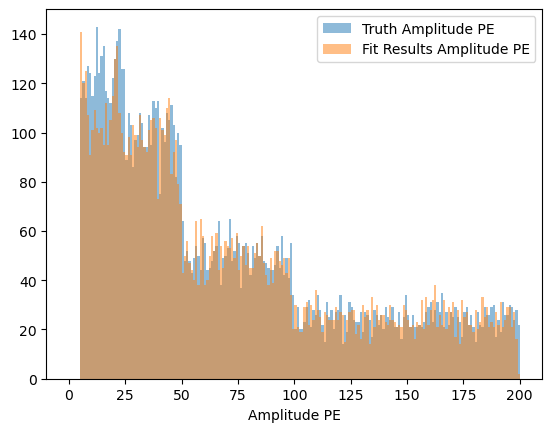

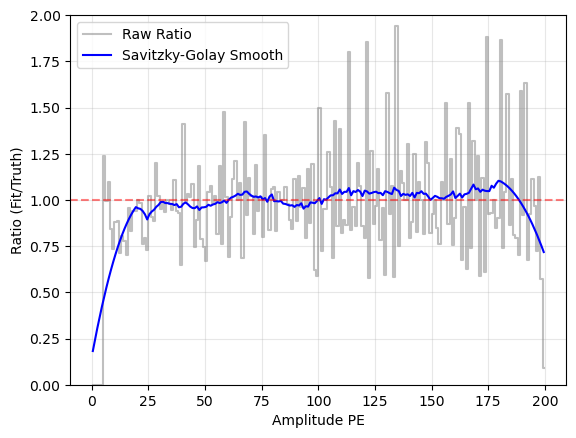

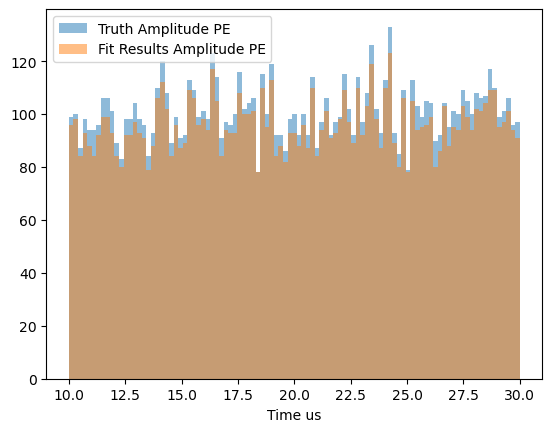

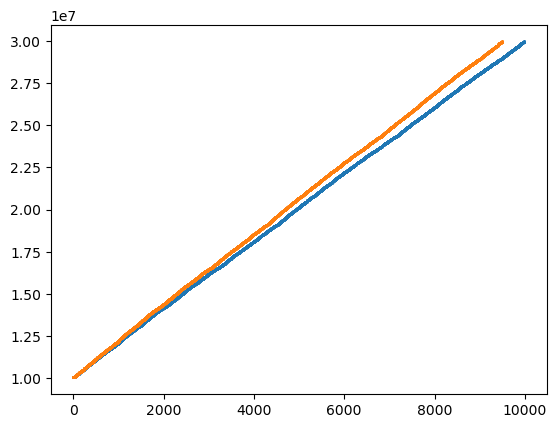

Truth count: 9986
Fit Results count: 9498
Ratio (Fit/Truth): 0.9511315842179051


In [ ]:
pe_bins = np.linspace(0, 200, 201)
plt.hist(truth['amplitude_pe'], bins=pe_bins, alpha=0.5, label='Truth Amplitude PE')
plt.hist(fit_results['amplitude_pe'], bins=pe_bins, alpha=0.5, label='Fit Results Amplitude PE')
# plt.hist(fit_results['amplitude_pe'] * (np.mean(truth['amplitude_pe']) / np.mean(fit_results['amplitude_pe'])), bins=pe_bins, alpha=0.5, label='Fit Results Amplitude PE')
plt.legend()
plt.xlabel('Amplitude PE')
plt.show()

from scipy.signal import savgol_filter
truth_counts, _ = np.histogram(truth['amplitude_pe'], bins=pe_bins)
fit_counts, _ = np.histogram(fit_results['amplitude_pe'], bins=pe_bins)
ratio = np.divide(fit_counts, truth_counts, out=np.zeros_like(fit_counts, dtype=float), where=truth_counts!=0)
smoothed_ratio = savgol_filter(ratio, window_length=40, polyorder=2)
bin_centers = (pe_bins[:-1] + pe_bins[1:]) / 2

plt.step(bin_centers, ratio, alpha=0.5, color='gray', label='Raw Ratio', where='mid')
plt.plot(bin_centers, smoothed_ratio, color='blue', label='Savitzky-Golay Smooth')
plt.axhline(1.0, color='red', linestyle='--', alpha=0.5) # Reference line
plt.xlabel('Amplitude PE')
plt.ylabel('Ratio (Fit/Truth)')
plt.ylim(0, 2) # Adjust based on your expected performance
plt.legend()
plt.grid(alpha=0.3)
plt.show()

t_bins = np.linspace(10, 30, 100)
plt.hist(truth['time_us'] / 1e6, bins=t_bins, alpha=0.5, label='Truth Amplitude PE')
plt.hist(fit_results['time_us'] / 1e6, bins=t_bins, alpha=0.5, label='Fit Results Amplitude PE')
plt.legend()
plt.xlabel('Time us')
plt.show()

plt.scatter(range(len(truth['time_us'])), truth['time_us'], s=1)
plt.scatter(range(len(fit_results['time_us'])), fit_results['time_us'], s=1)
plt.show()

print("Truth count:", len(truth))
print("Fit Results count:", len(fit_results))
print("Ratio (Fit/Truth):", len(fit_results) / len(truth))

In [ ]:
def mutual_nearest_match(truth, fit, tol_us=10.0):
    t = truth[['time_us', 'amplitude_pe']].copy().sort_values('time_us').reset_index()
    t = t.rename(columns={'index': 'truth_idx', 'amplitude_pe': 'truth_amp', 'time_us': 'truth_time_us'})

    f = fit[['time_us', 'amplitude_pe']].copy().sort_values('time_us').reset_index()
    f = f.rename(columns={'index': 'fit_idx', 'amplitude_pe': 'fit_amp', 'time_us': 'fit_time_us'})

    # nearest fit for each truth
    m1 = pd.merge_asof(
        t, f,
        left_on='truth_time_us',
        right_on='fit_time_us',
        direction='nearest',
        tolerance=tol_us
    )

    # nearest truth for each fit
    m2 = pd.merge_asof(
        f, t[['truth_idx', 'truth_time_us']],
        left_on='fit_time_us',
        right_on='truth_time_us',
        direction='nearest',
        tolerance=tol_us
    ).rename(columns={'truth_idx': 'back_truth_idx'})

    m = m1.merge(m2[['fit_idx', 'back_truth_idx']], on='fit_idx', how='left')

    matched = m[
        (~m['fit_idx'].isna()) &
        (m['truth_idx'] == m['back_truth_idx'])
    ].copy()

    matched['dt_us'] = matched['fit_time_us'] - matched['truth_time_us']
    matched['amp_ratio'] = matched['fit_amp'] / matched['truth_amp']
    matched['amp_diff'] = matched['fit_amp'] - matched['truth_amp']

    unmatched_truth = t[~t['truth_idx'].isin(matched['truth_idx'])].copy()
    unmatched_fit = f[~f['fit_idx'].isin(matched['fit_idx'])].copy()

    return matched, unmatched_truth, unmatched_fit

def mark_isolated_truth(truth, isolation_us=200.0):
    t = truth[['time_us', 'amplitude_pe']].copy().sort_values('time_us').reset_index()
    t = t.rename(columns={'index': 'truth_idx'})
    
    prev_dt = np.full(len(t), np.inf)
    next_dt = np.full(len(t), np.inf)

    if len(t) > 1:
        prev_dt[1:] = t['time_us'].values[1:] - t['time_us'].values[:-1]
        next_dt[:-1] = t['time_us'].values[1:] - t['time_us'].values[:-1]

    t['prev_dt_us'] = prev_dt
    t['next_dt_us'] = next_dt
    t['isolated'] = (t['prev_dt_us'] > isolation_us) & (t['next_dt_us'] > isolation_us)
    return t

matched, unmatched_truth, unmatched_fit = mutual_nearest_match(truth, fit_results, tol_us=5.0)

truth_iso = mark_isolated_truth(truth, isolation_us=200.0)
matched_iso = matched.merge(truth_iso[['truth_idx', 'isolated']], on='truth_idx', how='left')
matched_iso = matched_iso[matched_iso['isolated']].copy()

In [ ]:
print("Matched pulses:", len(matched))
print("Unmatched truth:", len(unmatched_truth))
print("Unmatched fit:", len(unmatched_fit))

print("\nFirst few unmatched truth pulses:")
print(unmatched_truth.head(20))

print("\nFirst few unmatched fit pulses:")
print(unmatched_fit.head(20))

Matched pulses: 9351
Unmatched truth: 635
Unmatched fit: 147

First few unmatched truth pulses:
     truth_idx  truth_time_us  truth_amp
20          20   1.003483e+07          6
44          44   1.009096e+07          5
52          52   1.010677e+07         12
84          84   1.017079e+07          9
116        116   1.023466e+07         11
156        156   1.032377e+07          6
176        176   1.036889e+07         14
200        200   1.041367e+07         21
204        204   1.041626e+07          5
280        280   1.059820e+07         10
308        308   1.067236e+07          5
324        324   1.070189e+07          6
332        332   1.071287e+07         12
352        352   1.076327e+07         20
360        360   1.076929e+07          7
368        368   1.078256e+07          6
384        384   1.080954e+07         24
396        396   1.085326e+07         15
408        408   1.086702e+07          8
416        416   1.088443e+07         11

First few unmatched fit pulses:
      fit_

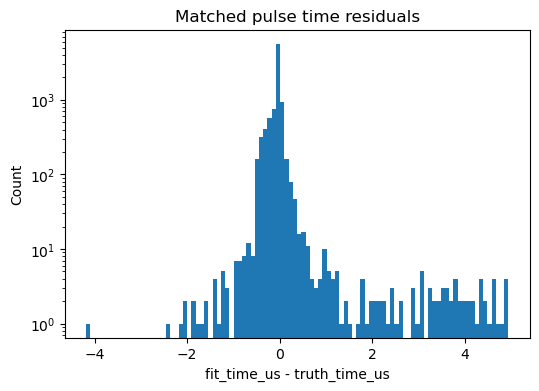

count    9351.000000
mean       -0.025535
std         0.367396
min        -4.189785
25%        -0.076695
50%         0.001097
75%         0.005272
max         4.940706
Name: dt_us, dtype: float64


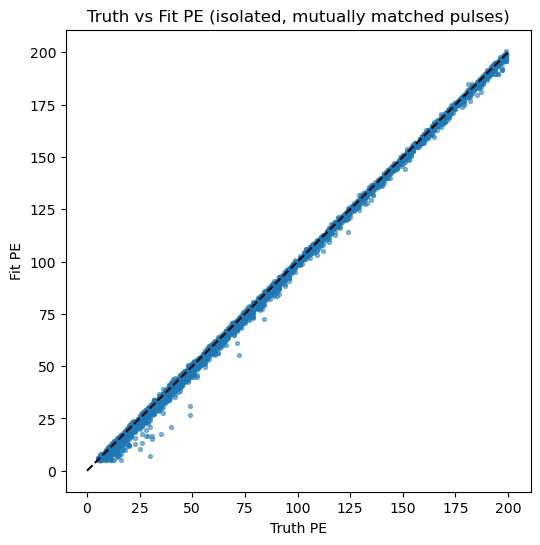

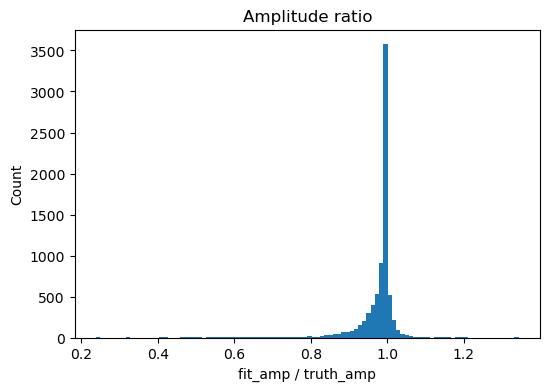

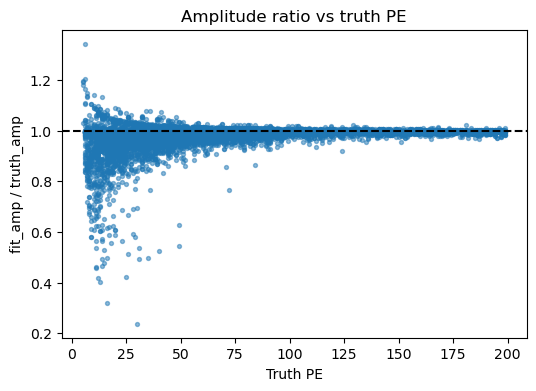

         truth_amp      fit_amp    amp_ratio     amp_diff
count  7653.000000  7653.000000  7653.000000  7653.000000
mean     72.141252    71.352496     0.976883    -0.788756
std      53.560734    53.708631     0.055000     1.398521
min       5.000000     5.001000     0.237967   -22.861000
25%      29.000000    27.893000     0.972515    -1.220000
50%      55.000000    53.811000     0.993825    -0.276000
75%     105.000000   104.740000     0.998263    -0.159000
max     199.000000   200.778000     1.343500     3.778000


In [ ]:
plt.figure(figsize=(6,4))
plt.hist(matched['dt_us'], bins=100)
plt.xlabel("fit_time_us - truth_time_us")
plt.ylabel("Count")
plt.title("Matched pulse time residuals")
plt.yscale('log')
plt.show()

print(matched['dt_us'].describe())

plt.figure(figsize=(6,6))
plt.scatter(matched_iso['truth_amp'], matched_iso['fit_amp'], s=8, alpha=0.5)
mx = max(matched_iso['truth_amp'].max(), matched_iso['fit_amp'].max())
plt.plot([0, mx], [0, mx], 'k--')
plt.xlabel("Truth PE")
plt.ylabel("Fit PE")
plt.title("Truth vs Fit PE (isolated, mutually matched pulses)")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(matched_iso['amp_ratio'], bins=100)
plt.xlabel("fit_amp / truth_amp")
plt.ylabel("Count")
plt.title("Amplitude ratio")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(matched_iso['truth_amp'], matched_iso['amp_ratio'], s=8, alpha=0.5)
plt.axhline(1.0, linestyle='--', color='k')
plt.xlabel("Truth PE")
plt.ylabel("fit_amp / truth_amp")
plt.title("Amplitude ratio vs truth PE")
plt.show()

print(matched_iso[['truth_amp', 'fit_amp', 'amp_ratio', 'amp_diff']].describe())

## All 4 Segments (Min_Gap 20 us)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

plt.style.use("seaborn-paper")
FIG_WIDTH = 468.0 / 72.27
FIG_HEIGHT = FIG_WIDTH * 0.75
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.titlesize": 14,
    "figure.autolayout": True,
    "savefig.bbox": "tight",
})

segments = ["12", "34", "56", "78"]
pe_bins = np.linspace(0, 200, 201)
bin_centers = (pe_bins[:-1] + pe_bins[1:]) / 2

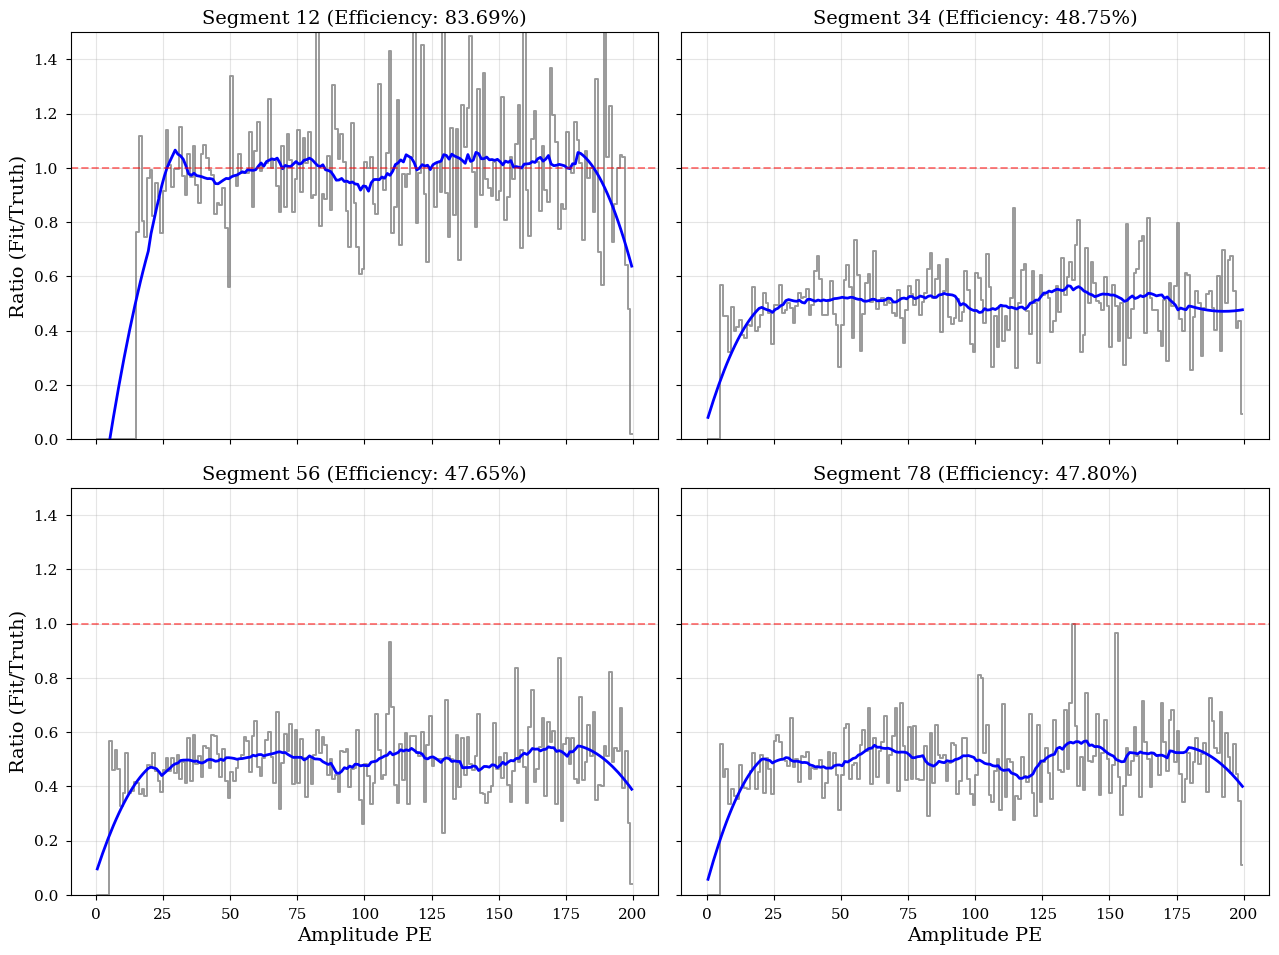

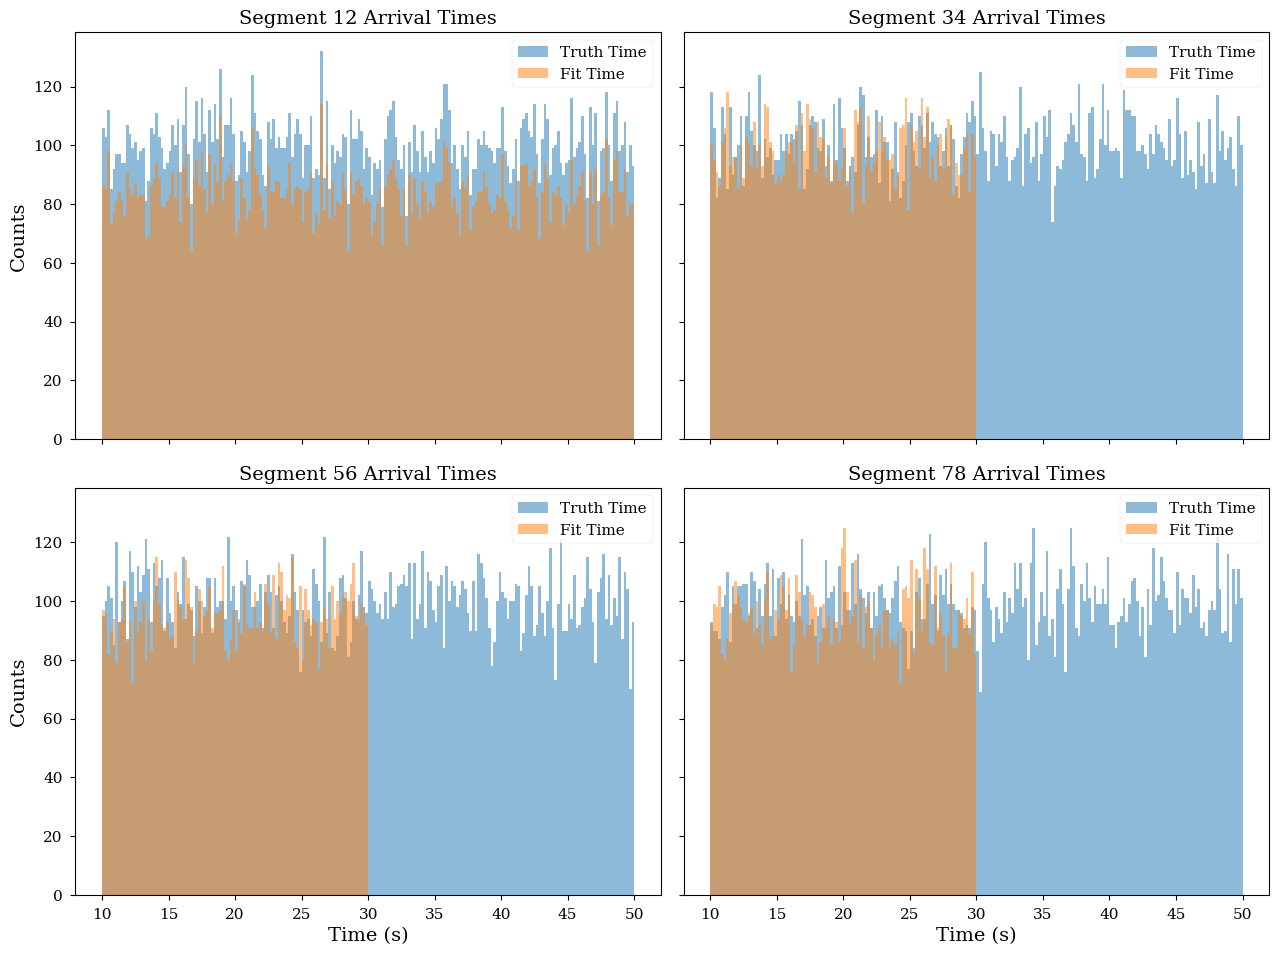

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(2*FIG_WIDTH, 2*FIG_HEIGHT), sharex=True, sharey=True)
axes = axes.flatten()

for i, seg in enumerate(segments):
    ax = axes[i]

    truth = pd.read_csv(f"mc_truth_10s_clean_seg{seg}.csv")
    fit_results = pd.read_csv(f"fit_results_seg{seg}.csv")

    truth_counts, _ = np.histogram(truth['amplitude_pe'], bins=pe_bins)
    fit_counts, _ = np.histogram(fit_results['amplitude_pe'], bins=pe_bins)

    ratio = np.divide(fit_counts, truth_counts, out=np.zeros_like(fit_counts, dtype=float), where=truth_counts!=0)
    smoothed_ratio = savgol_filter(ratio, window_length=40, polyorder=2)

    ax.step(bin_centers, ratio, alpha=0.8, color='gray', label='Raw Ratio', where='mid')
    ax.plot(bin_centers, smoothed_ratio, color='blue', linewidth=2, label='SG Smooth')
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.5)

    ratio_val = len(fit_results) / len(truth) # [cite: 215]
    ax.set_title(f"Segment {seg} (Efficiency: {ratio_val:.2%})", fontsize=14)
    ax.grid(alpha=0.33)
    ax.set_ylim(0, 1.5)
    
    if i >= 2: ax.set_xlabel('Amplitude PE')
    if i % 2 == 0: ax.set_ylabel('Ratio (Fit/Truth)')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(2*FIG_WIDTH, 2*FIG_HEIGHT), sharex=True, sharey=True)
axes = axes.flatten()
t_bins = np.linspace(10, 50, 201)

for i, seg in enumerate(segments):
    ax = axes[i]
    truth = pd.read_csv(f"mc_truth_10s_clean_seg{seg}.csv")
    fit_results = pd.read_csv(f"fit_results_seg{seg}.csv")
    
    ax.hist(truth['time_us'] / 1e6, bins=t_bins, alpha=0.5, label='Truth Time', color='C0')
    ax.hist(fit_results['time_us'] / 1e6, bins=t_bins, alpha=0.5, label='Fit Time', color='C1')
    
    ax.set_title(f"Segment {seg} Arrival Times")
    ax.legend()
    if i >= 2: ax.set_xlabel('Time (s)') # Scaling from your code 
    if i % 2 == 0: ax.set_ylabel('Counts')

plt.tight_layout()
plt.show()

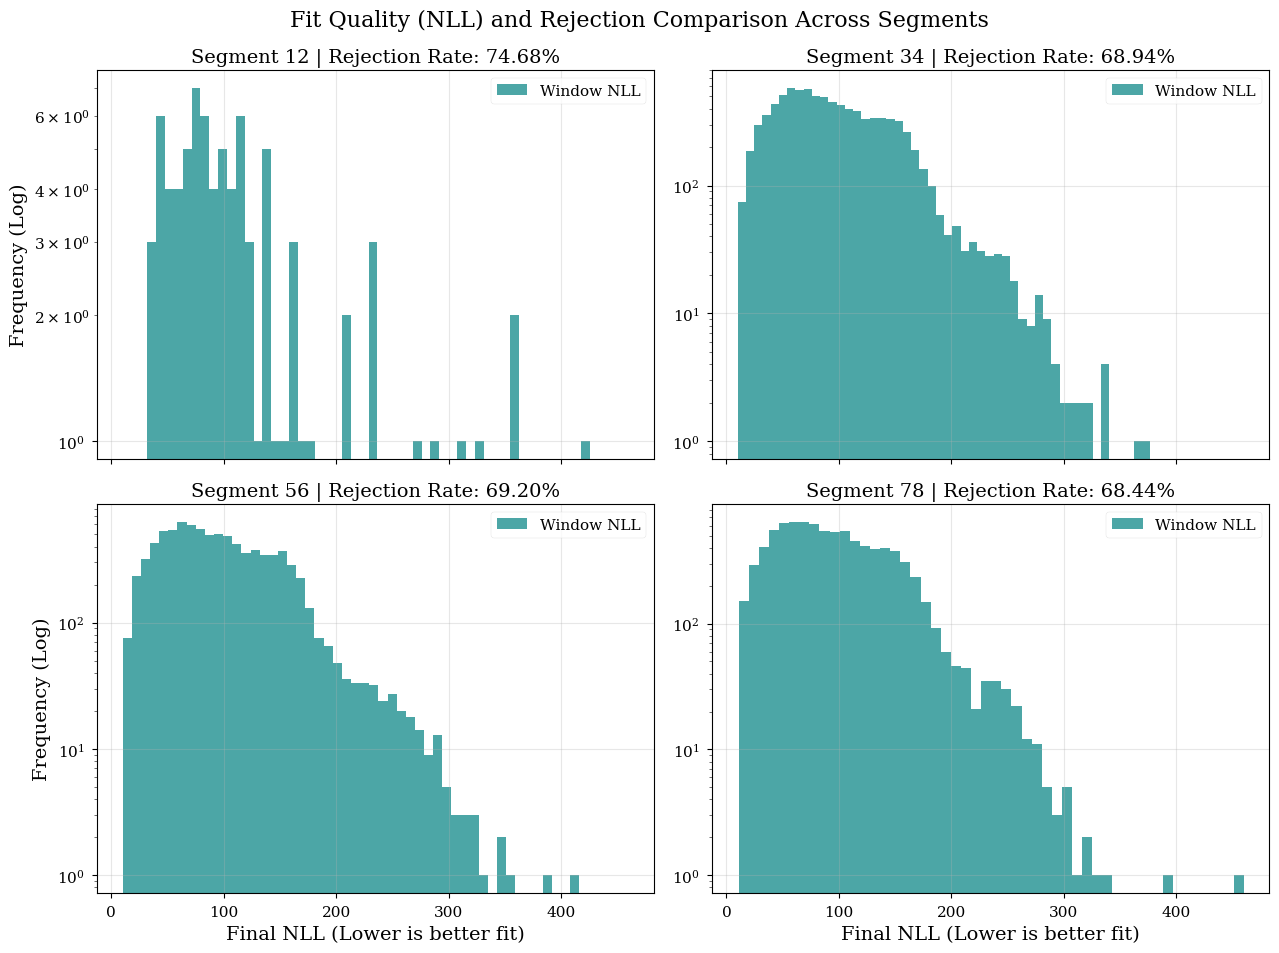

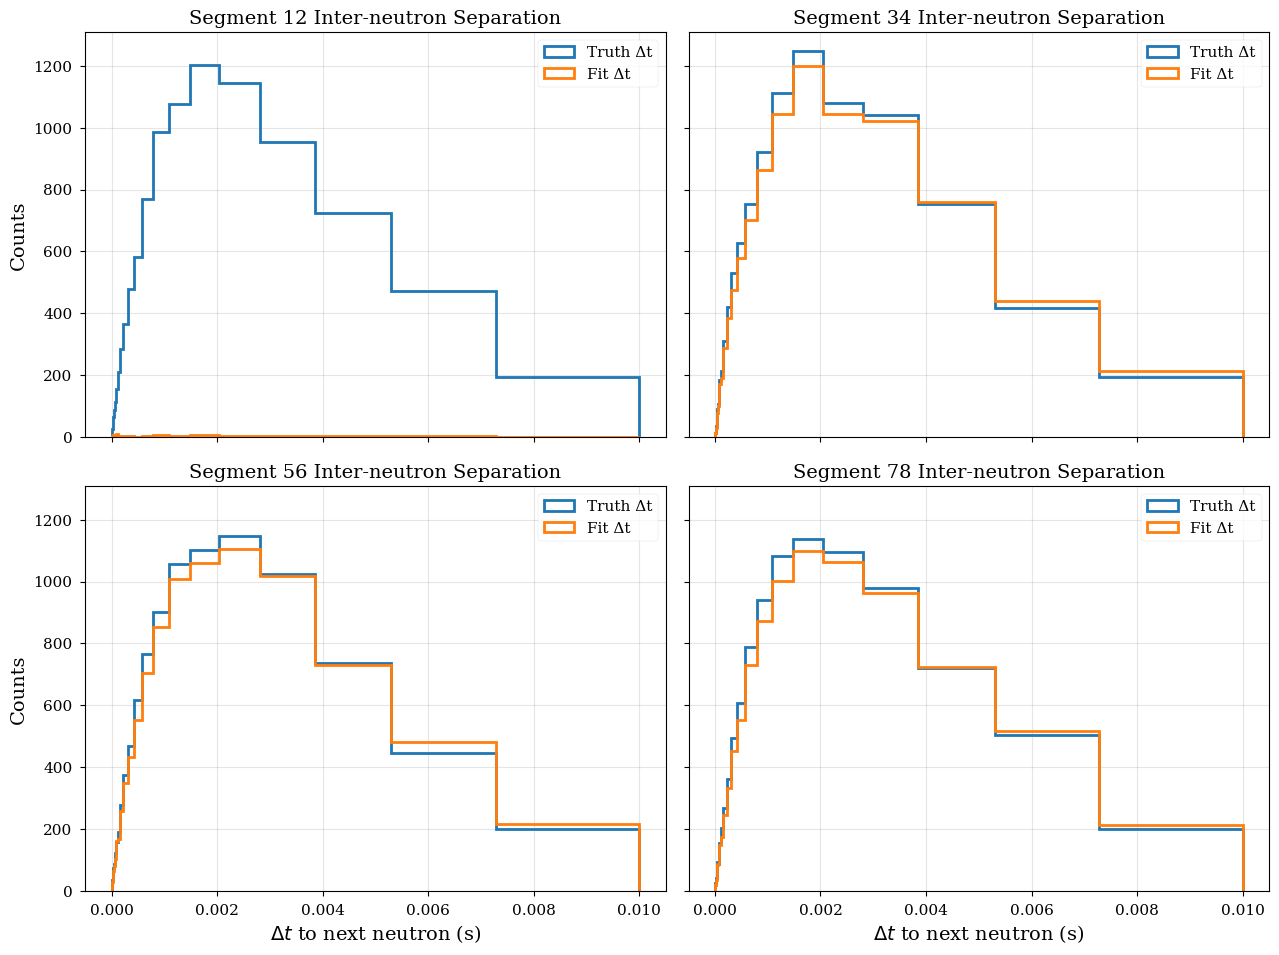

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(2*FIG_WIDTH, 2*FIG_HEIGHT), sharex=True)
axes = axes.flatten()

for i, seg in enumerate(segments):
    ax = axes[i]
    df_win = pd.read_csv(f"win_summaries_seg{seg}.csv")

    active_windows = df_win[df_win['seed_count'] > 0]

    ax.hist(active_windows['final_nll'], bins=50, color='teal', alpha=0.7, label='Window NLL')
    total_seeds = active_windows['seed_count'].sum()
    total_pulses = active_windows['pulse_count'].sum()
    rej_rate = 1 - (total_pulses / total_seeds)
    
    ax.set_title(f"Segment {seg} | Rejection Rate: {rej_rate:.2%}")
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    if i >= 2: ax.set_xlabel("Final NLL (Lower is better fit)")
    if i % 2 == 0: ax.set_ylabel("Frequency (Log)")

plt.suptitle("Fit Quality (NLL) and Rejection Comparison Across Segments", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

fig, axes = plt.subplots(
    2, 2,
    figsize=(2*FIG_WIDTH, 2*FIG_HEIGHT),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

dt_bins = np.logspace(-6, -2, 30)
for i, seg in enumerate(segments):
    ax = axes[i]

    truth = pd.read_csv(f"mc_truth_10s_clean_seg{seg}.csv")
    fit_results = pd.read_csv(f"fit_results_seg{seg}.csv")

    truth_t = truth["time_us"].dropna().sort_values().to_numpy()
    fit_t   = fit_results["time_us"].dropna().sort_values().to_numpy()

    truth_dt_s = np.diff(truth_t) * 1e-6
    fit_dt_s   = np.diff(fit_t) * 1e-6

    truth_dt_s = truth_dt_s[np.isfinite(truth_dt_s) & (truth_dt_s > 0)]
    fit_dt_s   = fit_dt_s[np.isfinite(fit_dt_s) & (fit_dt_s > 0)]

    ax.hist(
        truth_dt_s,
        bins=dt_bins,
        histtype="step",
        linewidth=2,
        label="Truth Δt",
        color="C0"
    )
    ax.hist(
        fit_dt_s,
        bins=dt_bins,
        histtype="step",
        linewidth=2,
        label="Fit Δt",
        color="C1"
    )

    ax.set_title(f"Segment {seg} Inter-neutron Separation")
    ax.grid(alpha=0.33)
    ax.legend()

    if i >= 2:
        ax.set_xlabel(r"$\Delta t$ to next neutron (s)")
    if i % 2 == 0:
        ax.set_ylabel("Counts")

plt.tight_layout()
plt.show()

## All 4 Segments (Min_Gap 100 us)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

plt.style.use("seaborn-paper")
FIG_WIDTH = 468.0 / 72.27
FIG_HEIGHT = FIG_WIDTH * 0.75
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.titlesize": 14,
    "figure.autolayout": True,
    "savefig.bbox": "tight",
})

segments = ["12", "34", "56", "78"]
pe_bins = np.linspace(0, 200, 201)
bin_centers = (pe_bins[:-1] + pe_bins[1:]) / 2

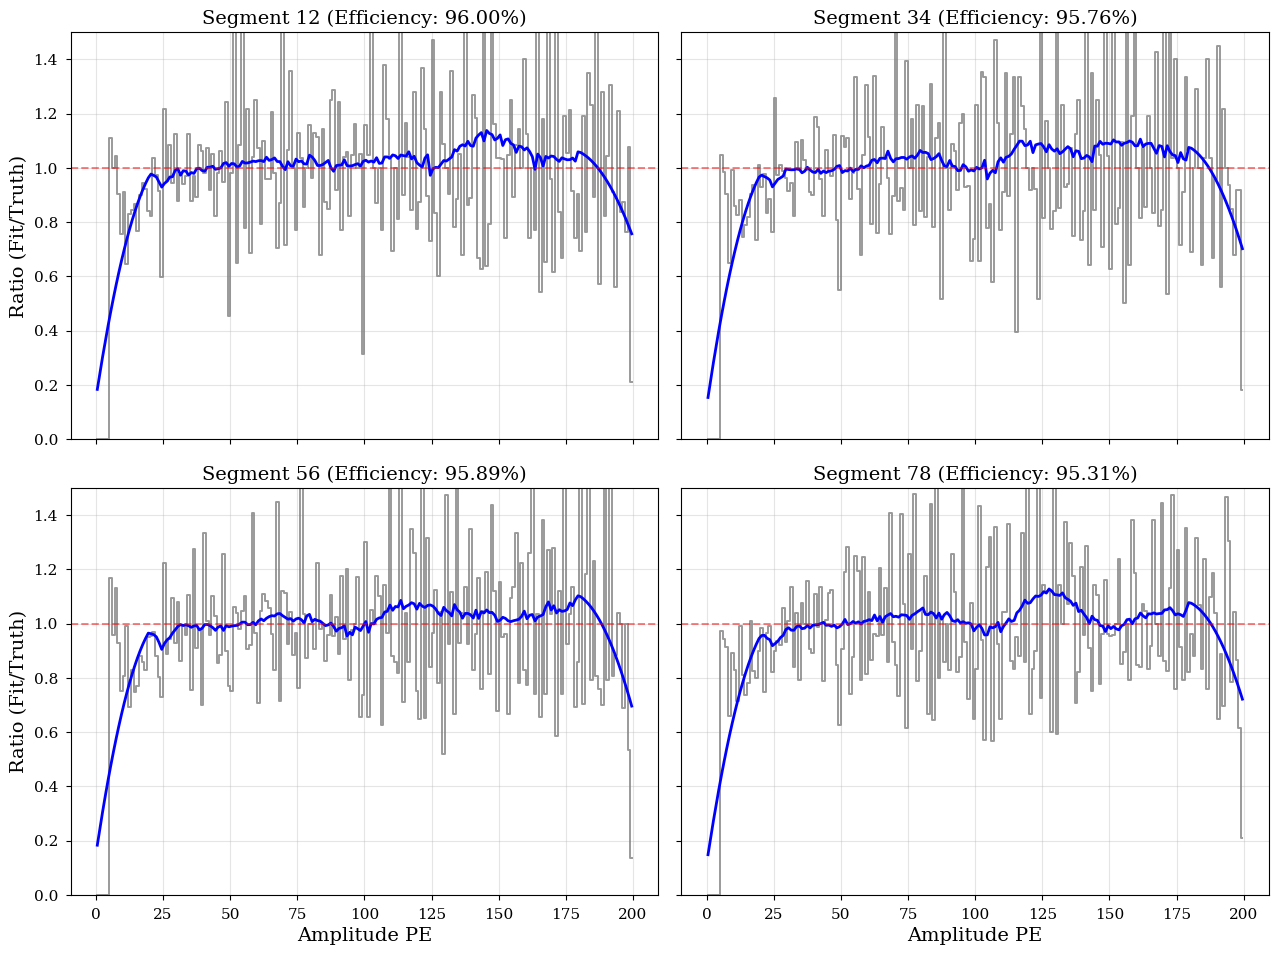

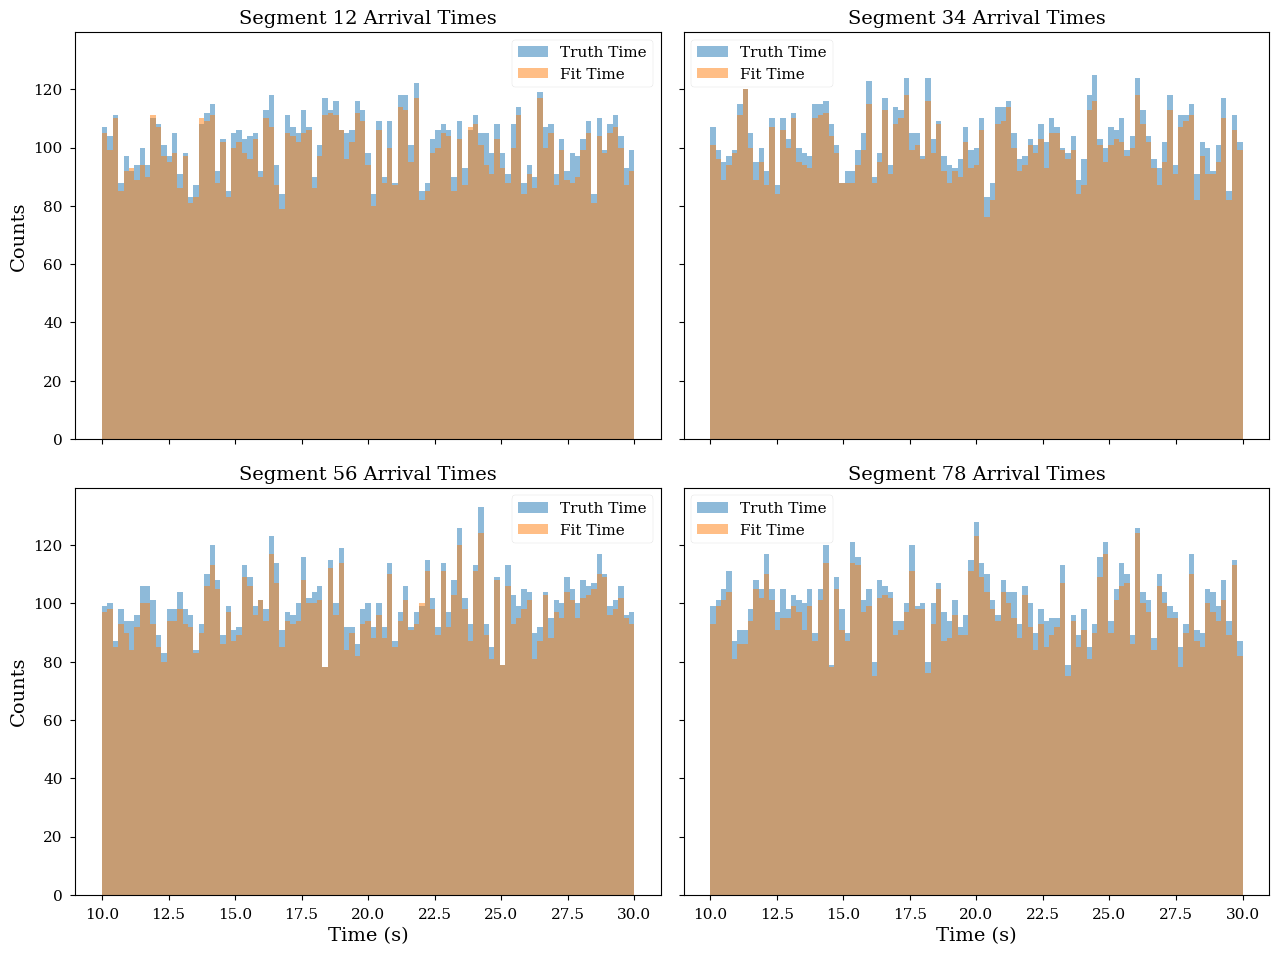

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(2*FIG_WIDTH, 2*FIG_HEIGHT), sharex=True, sharey=True)
axes = axes.flatten()

for i, seg in enumerate(segments):
    ax = axes[i]

    truth = pd.read_csv(f"mc_truth_5s_clean_seg{seg}.csv")
    fit_results = pd.read_csv(f"fit_results_seg{seg}_2.csv")

    truth_counts, _ = np.histogram(truth['amplitude_pe'], bins=pe_bins)
    fit_counts, _ = np.histogram(fit_results['amplitude_pe'], bins=pe_bins)

    ratio = np.divide(fit_counts, truth_counts, out=np.zeros_like(fit_counts, dtype=float), where=truth_counts!=0)
    smoothed_ratio = savgol_filter(ratio, window_length=40, polyorder=2)

    ax.step(bin_centers, ratio, alpha=0.8, color='gray', label='Raw Ratio', where='mid')
    ax.plot(bin_centers, smoothed_ratio, color='blue', linewidth=2, label='SG Smooth')
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.5)

    ratio_val = len(fit_results) / len(truth) # [cite: 215]
    ax.set_title(f"Segment {seg} (Efficiency: {ratio_val:.2%})", fontsize=14)
    ax.grid(alpha=0.33)
    ax.set_ylim(0, 1.5)
    
    if i >= 2: ax.set_xlabel('Amplitude PE')
    if i % 2 == 0: ax.set_ylabel('Ratio (Fit/Truth)')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(2*FIG_WIDTH, 2*FIG_HEIGHT), sharex=True, sharey=True)
axes = axes.flatten()
t_bins = np.linspace(10, 30, 100)

for i, seg in enumerate(segments):
    ax = axes[i]
    truth = pd.read_csv(f"mc_truth_5s_clean_seg{seg}.csv")
    fit_results = pd.read_csv(f"fit_results_seg{seg}_2.csv")
    
    ax.hist(truth['time_us'] / 1e6, bins=t_bins, alpha=0.5, label='Truth Time', color='C0')
    ax.hist(fit_results['time_us'] / 1e6, bins=t_bins, alpha=0.5, label='Fit Time', color='C1')
    
    ax.set_title(f"Segment {seg} Arrival Times")
    ax.legend()
    if i >= 2: ax.set_xlabel('Time (s)') # Scaling from your code 
    if i % 2 == 0: ax.set_ylabel('Counts')

plt.tight_layout()
plt.show()

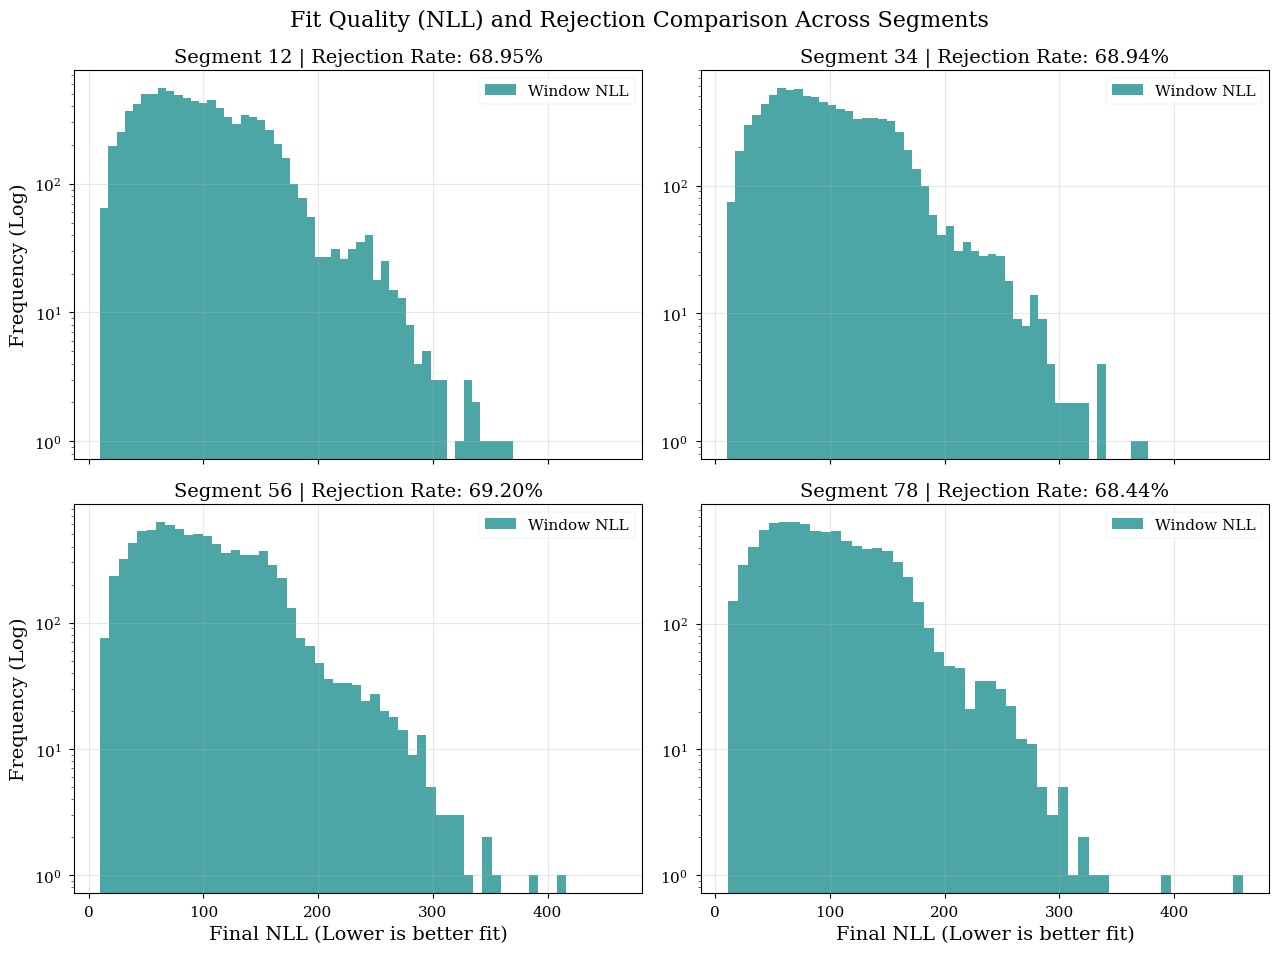

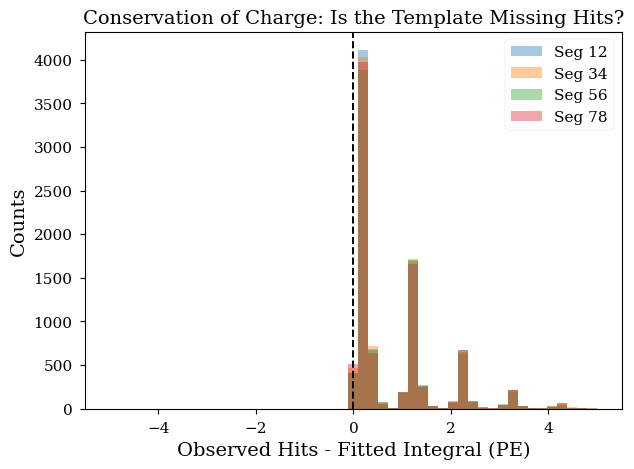

In [277]:
fig, axes = plt.subplots(2, 2, figsize=(2*FIG_WIDTH, 2*FIG_HEIGHT), sharex=True)
axes = axes.flatten()

for i, seg in enumerate(segments):
    ax = axes[i]
    df_win = pd.read_csv(f"win_summaries_seg{seg}.csv")

    active_windows = df_win[df_win['seed_count'] > 0]

    ax.hist(active_windows['final_nll'], bins=50, color='teal', alpha=0.7, label='Window NLL')
    total_seeds = active_windows['seed_count'].sum()
    total_pulses = active_windows['pulse_count'].sum()
    rej_rate = 1 - (total_pulses / total_seeds)
    
    ax.set_title(f"Segment {seg} | Rejection Rate: {rej_rate:.2%}")
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    if i >= 2: ax.set_xlabel("Final NLL (Lower is better fit)")
    if i % 2 == 0: ax.set_ylabel("Frequency (Log)")

plt.suptitle("Fit Quality (NLL) and Rejection Comparison Across Segments", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))
for seg in segments:
    df_win = pd.read_csv(f"win_summaries_seg{seg}.csv")
    diff = df_win['observed_count'] - df_win['expected_count']
    plt.hist(diff, bins=np.linspace(-5, 5, 50), alpha=0.4, label=f'Seg {seg}')

plt.axvline(0, color='k', linestyle='--')
plt.xlabel("Observed Hits - Fitted Integral (PE)")
plt.ylabel("Counts")
plt.title("Conservation of Charge: Is the Template Missing Hits?")
plt.legend()
plt.show()

## Seg 12 With Different Rates (Min_Gap 100 us)

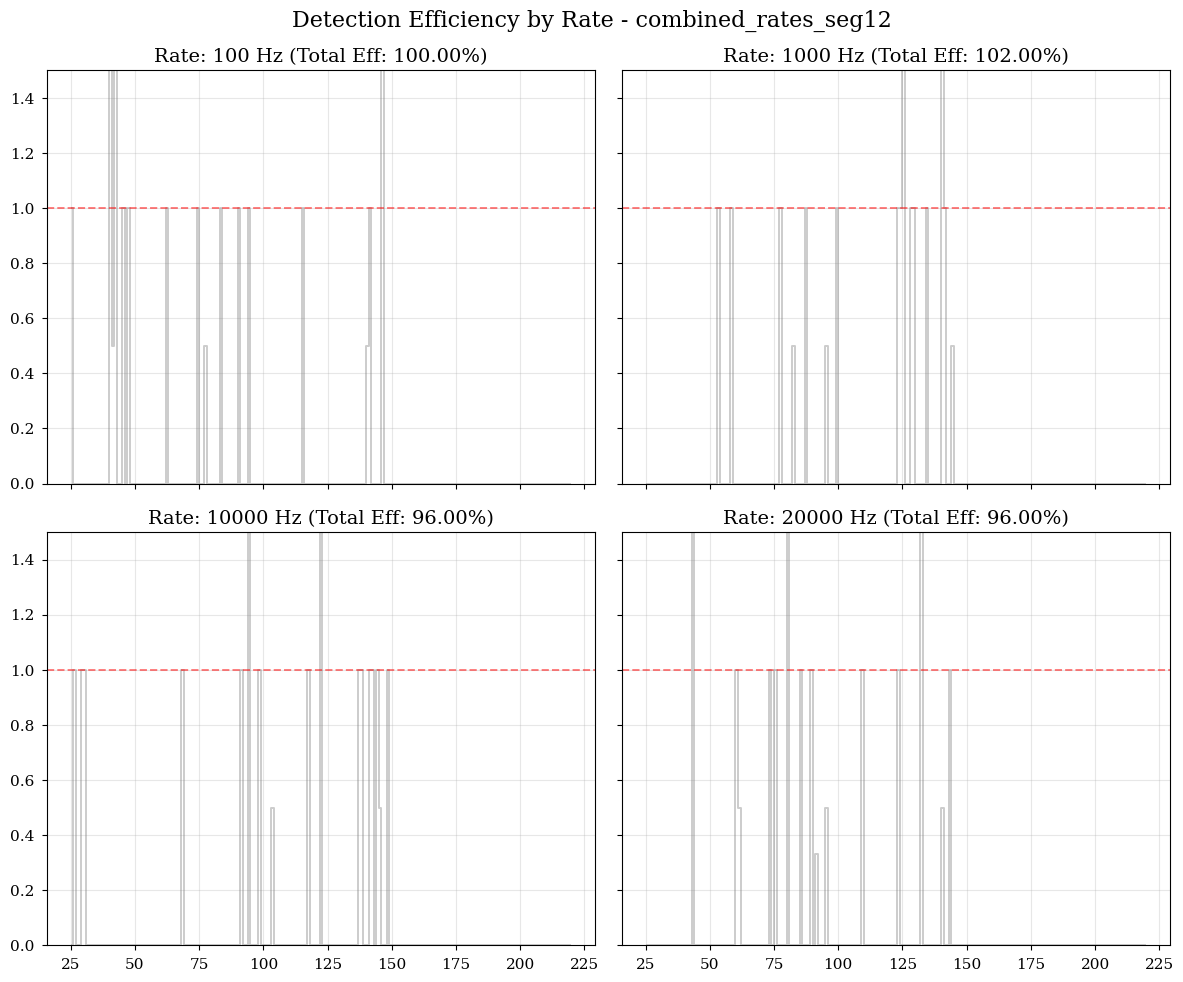

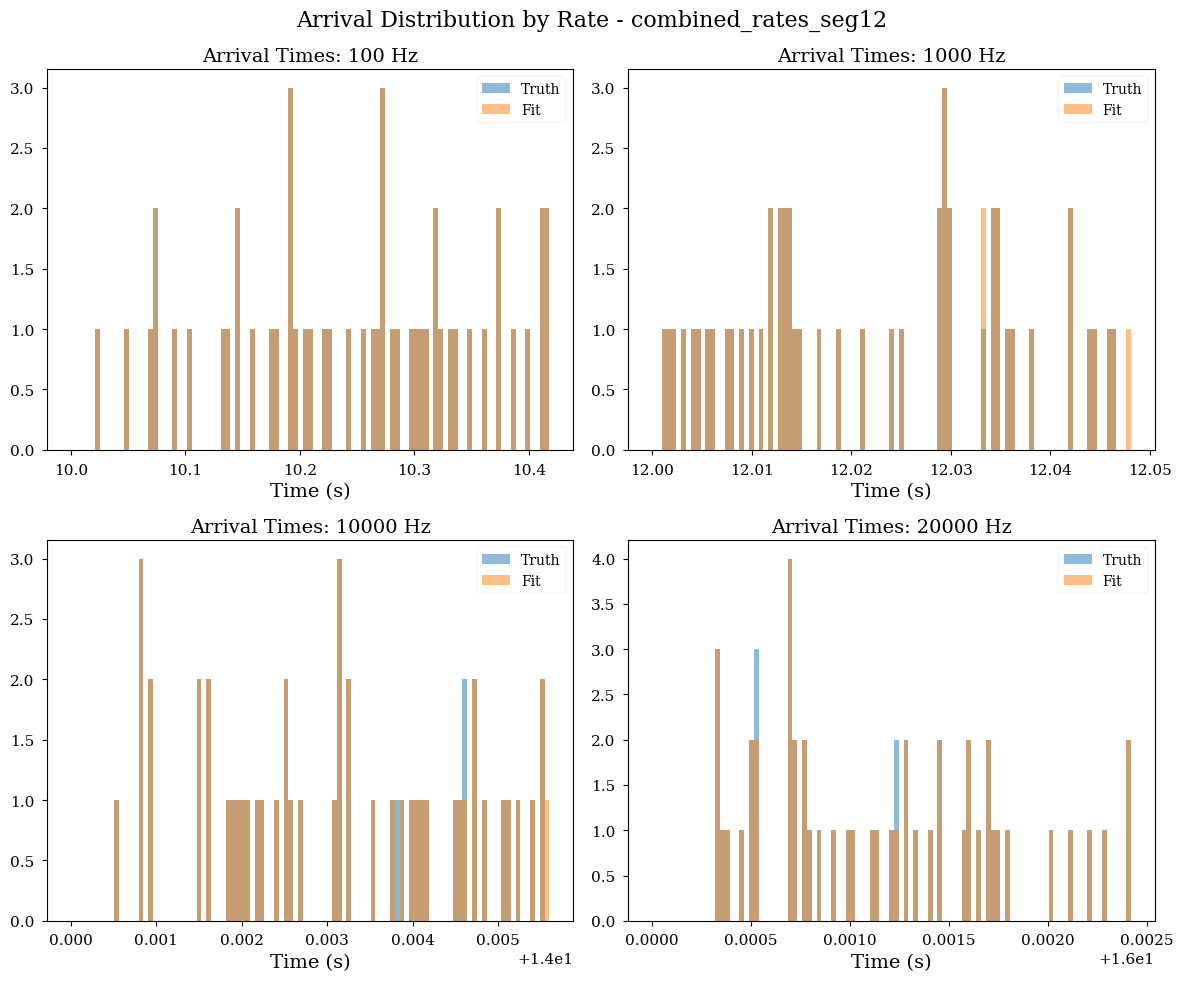

In [19]:
FILE_SUFFIX = "combined_rates_seg12"
RATES = [100, 1000, 10000, 20000]
DURATION_S = 2.0
PRE_TRIGGER_S = 10.0
PE_BINS = np.arange(25, 221)
BIN_CENTERS = (PE_BINS[:-1] + PE_BINS[1:]) / 2

truth_df = pd.read_csv(f"mc_truth_{FILE_SUFFIX}.csv")
fit_df = pd.read_csv(f"fit_results_seg12_combined_rates.csv")

# --- 1. Efficiency Plots (Fit/Truth Ratio) ---
fig1, axes1 = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes1 = axes1.flatten()

# --- 2. Arrival Time Plots ---
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10), sharex=False, sharey=False)
axes2 = axes2.flatten()

for i, rate in enumerate(RATES):
    t_start_us = (PRE_TRIGGER_S + i * DURATION_S) * 1e6
    t_end_us = t_start_us + (DURATION_S * 1e6)
    
    # Filter Truth (using the helper column we added)
    truth_sub = truth_df[truth_df['target_rate_hz'] == rate]
    
    # Filter Fit Results (using time slicing)
    fit_sub = fit_df[(fit_df['time_us'] >= t_start_us) & (fit_df['time_us'] < t_end_us)]

    t_end_us = fit_sub['time_us'].iloc[len(fit_sub['time_us'])-1]

    # --- Efficiency Calculation ---
    truth_counts, _ = np.histogram(truth_sub['amplitude_pe'], bins=PE_BINS)
    fit_counts, _ = np.histogram(fit_sub['amplitude_pe'], bins=PE_BINS)
    
    ratio = np.divide(fit_counts, truth_counts, out=np.zeros_like(fit_counts, dtype=float), where=truth_counts!=0)
    
    # Savgol filter requires window < len(data); adjust if bins are few
    window_len = min(len(ratio) // 2, 11) 
    if window_len % 2 == 0: window_len += 1
    smoothed_ratio = savgol_filter(ratio, window_length=window_len, polyorder=2)

    # Plot Efficiency
    ax_eff = axes1[i]
    ax_eff.step(BIN_CENTERS, ratio, alpha=0.4, color='gray', label='Raw Ratio', where='mid')
    # ax_eff.plot(BIN_CENTERS, smoothed_ratio, color='blue', linewidth=2, label='SG Smooth')
    ax_eff.axhline(1.0, color='red', linestyle='--', alpha=0.5)
    
    eff_val = len(fit_sub) / len(truth_sub) if len(truth_sub) > 0 else 0
    ax_eff.set_title(f"Rate: {rate} Hz (Total Eff: {eff_val:.2%})")
    ax_eff.set_ylim(0, 1.5)
    ax_eff.grid(alpha=0.3)

    # Plot Arrival Times
    ax_time = axes2[i]
    t_bins = np.linspace(t_start_us / 1e6, t_end_us / 1e6, 100)
    
    ax_time.hist(truth_sub['time_us'] / 1e6, bins=t_bins, alpha=0.5, label='Truth', color='C0')
    ax_time.hist(fit_sub['time_us'] / 1e6, bins=t_bins, alpha=0.5, label='Fit', color='C1')
    
    ax_time.set_title(f"Arrival Times: {rate} Hz")
    ax_time.legend(fontsize='small')
    ax_time.set_xlabel("Time (s)")

# Formatting
fig1.suptitle(f"Detection Efficiency by Rate - {FILE_SUFFIX}", fontsize=16)
fig1.tight_layout(rect=[0, 0.03, 1, 0.95])

fig2.suptitle(f"Arrival Distribution by Rate - {FILE_SUFFIX}", fontsize=16)
fig2.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()